In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

In [6]:
# 🎨 Esto hace que todos los gráficos se vean modernos
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
# Cargar el dataset
df = pd.read_csv('amazon_sales_dataset.csv')

In [5]:
#preparar fechas
df['order_date'] = pd.to_datetime(df['order_date'])

In [7]:
# Agrupar ingresos por mes
monthly = df.set_index('order_date').resample('M')['total_revenue'].sum().reset_index()

C:\Users\mbalv\AppData\Local\Temp\ipykernel_1692\142718534.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index('order_date').resample('M')['total_revenue'].sum().reset_index()


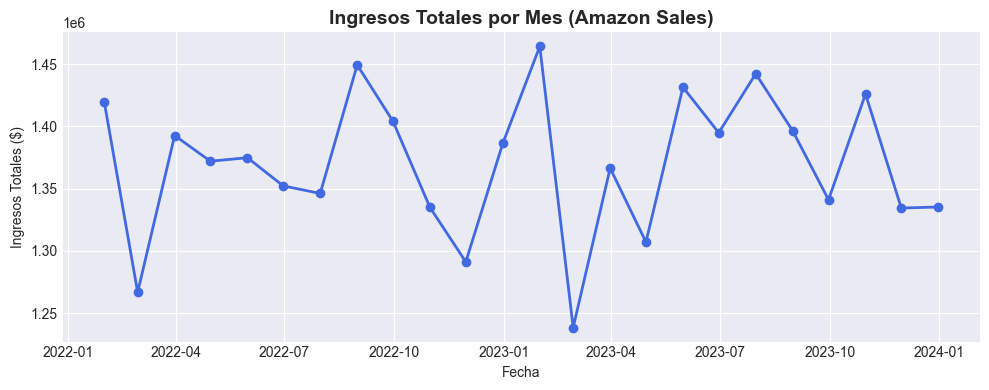

In [8]:
#Gráfico de Estacionalidad
plt.figure(figsize=(10, 4))
plt.plot(monthly['order_date'], monthly['total_revenue'], marker='o', color='royalblue', linewidth=2)
plt.title('Ingresos Totales por Mes (Amazon Sales)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Ingresos Totales ($)')
plt.tight_layout()
plt.show()

In [9]:
# Prueba de Augmented Dickey-Fuller
print("--- Prueba de Augmented Dickey-Fuller ---")
result_adf = adfuller(monthly['total_revenue'])
print(f'Estadístico ADF: {result_adf[0]}')
print(f'p-valor: {result_adf[1]:.10f}')
if result_adf[1] < 0.05:
    print("Conclusión: Rechazamos H0. La serie es estacionaria (No tiene estacionalidad o tendencia incontrolable).")

--- Prueba de Augmented Dickey-Fuller ---
Estadístico ADF: -5.894174810659393
p-valor: 0.0000002877
Conclusión: Rechazamos H0. La serie es estacionaria (No tiene estacionalidad o tendencia incontrolable).


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [11]:
# 1. Crear nuestra variable a predecir (Target)
# Vamos a predecir si una venta será "Alta" (por encima de la media) o "Baja"
mediana_revenue = df['total_revenue'].median()
df['revenue_alto'] = (df['total_revenue'] > mediana_revenue).astype(int)

In [12]:
# 2. Convertir variables de texto a números para el modelo (Label Encoding)
le = LabelEncoder()
df['product_category_enc'] = le.fit_transform(df['product_category'])
df['customer_region_enc'] = le.fit_transform(df['customer_region'])

In [13]:
# 3. Definir características (X) y objetivo (y)
X = df[['product_category_enc', 'price', 'discount_percent', 'quantity_sold', 'customer_region_enc', 'rating']]
y = df['revenue_alto']

In [14]:
# 4. Separar datos: 70% para aprender, 30% para probar (oculto al modelo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [15]:
# 5. Entrenar el Modelo (Random Forest)
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
# 6. Hacer predicciones con los datos ocultos
y_pred = rf.predict(X_test)
print("¡Modelo entrenado y predicciones realizadas exitosamente!")

¡Modelo entrenado y predicciones realizadas exitosamente!


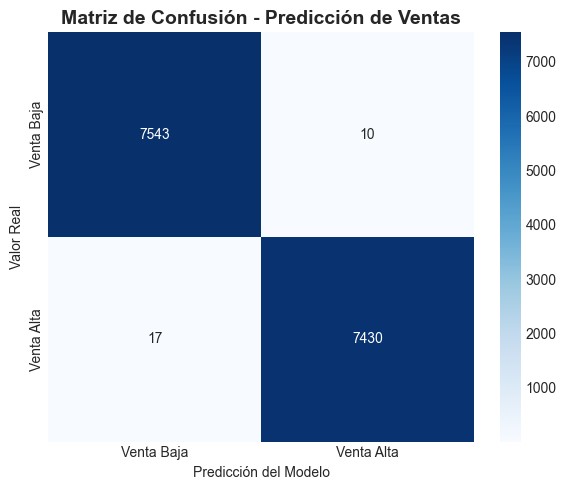

              precision    recall  f1-score   support

  Venta Baja       1.00      1.00      1.00      7553
  Venta Alta       1.00      1.00      1.00      7447

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000



In [17]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Crear la matriz de confusión visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Venta Baja', 'Venta Alta'], 
            yticklabels=['Venta Baja', 'Venta Alta'])
plt.title('Matriz de Confusión - Predicción de Ventas', fontsize=14, fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

# 2. Mostrar el reporte técnico (Opcional, pero bueno para tener a mano)
print(classification_report(y_test, y_pred, target_names=['Venta Baja', 'Venta Alta']))
